# Matrix Factorisation on Movie Lens 1M dataset
Dataset from: [Movie Lens 1M Dataset](https://grouplens.org/datasets/movielens/1m/)

In [3]:
import pandas as pd
import plotly as px

### Load dataset

In [4]:
def load_movielens_movies(path: str = "Dataset/ml-1m/movies.dat") -> pd.DataFrame:
    return pd.read_csv(
        path,
        sep="::",
        engine="python",
        names=["movie_id", "title", "genres"],
        encoding="latin-1",
    )

def load_movielens_ratings(path: str = "Dataset/ml-1m/ratings.dat") -> pd.DataFrame:
    return pd.read_csv(
        path,
        sep="::",
        engine="python",
        names=["user_id", "movie_id", "rating", "timestamp"],
        encoding="latin-1",
    )

def preprocess_data():
    """
    Merges movies and ratings on movieId.
    """
    movies = load_movielens_movies()
    ratings = load_movielens_ratings()
    merged = pd.merge(ratings, movies, on="movie_id")
    # Convert timestamps from unix
    merged["timestamp"] = pd.to_datetime(merged["timestamp"], unit='s')
    return merged

In [5]:
df = preprocess_data()

In [6]:
df.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,2000-12-31 22:12:40,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,2000-12-31 22:32:48,My Fair Lady (1964),Musical|Romance
3,1,3408,4,2000-12-31 22:04:35,Erin Brockovich (2000),Drama
4,1,2355,5,2001-01-06 23:38:11,"Bug's Life, A (1998)",Animation|Children's|Comedy


### EDA

<Axes: xlabel='Rating', ylabel='Count'>

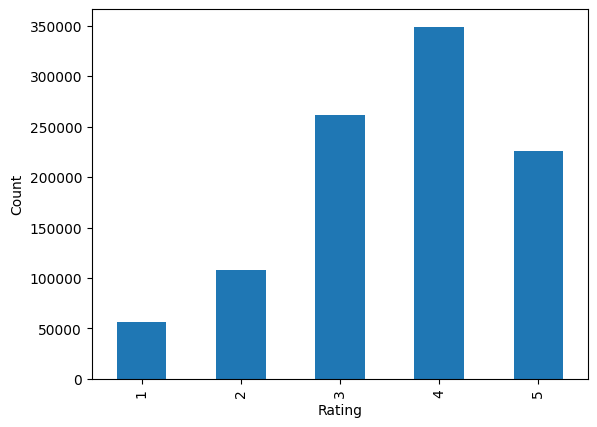

In [7]:
df.rating.value_counts().sort_index().plot(kind="bar", xlabel="Rating", ylabel="Count")

<Axes: xlabel='timestamp'>

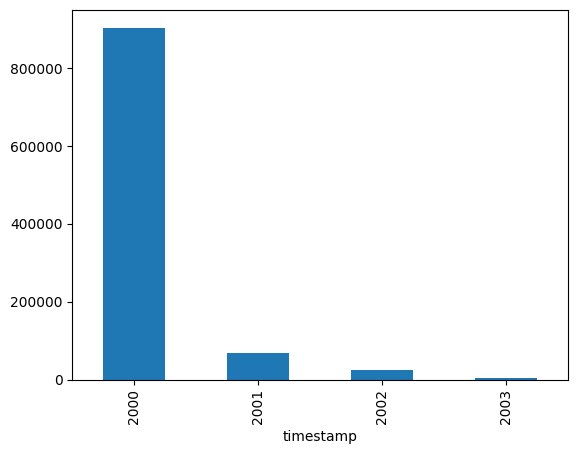

In [8]:
df.timestamp.groupby(df.timestamp.dt.year).count().plot(kind="bar")

In [9]:
df['genres'] = df['genres'].apply(lambda x: x.split('|'))

In [10]:
df.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,2000-12-31 22:12:40,One Flew Over the Cuckoo's Nest (1975),[Drama]
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),"[Animation, Children's, Musical]"
2,1,914,3,2000-12-31 22:32:48,My Fair Lady (1964),"[Musical, Romance]"
3,1,3408,4,2000-12-31 22:04:35,Erin Brockovich (2000),[Drama]
4,1,2355,5,2001-01-06 23:38:11,"Bug's Life, A (1998)","[Animation, Children's, Comedy]"


In [11]:
movies_df_exploded = df.explode("genres")

In [12]:
movies_df_exploded

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,2000-12-31 22:12:40,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),Animation
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),Children's
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),Musical
2,1,914,3,2000-12-31 22:32:48,My Fair Lady (1964),Musical
...,...,...,...,...,...,...
1000207,6040,1096,4,2000-04-26 02:20:48,Sophie's Choice (1982),Drama
1000208,6040,1097,4,2000-04-26 02:19:29,E.T. the Extra-Terrestrial (1982),Children's
1000208,6040,1097,4,2000-04-26 02:19:29,E.T. the Extra-Terrestrial (1982),Drama
1000208,6040,1097,4,2000-04-26 02:19:29,E.T. the Extra-Terrestrial (1982),Fantasy


In [13]:
px.histogram(movies_df_exploded, x="genres", height=400, title="Movie count by genre").update_xaxes(categoryorder="total descending")

AttributeError: module 'plotly' has no attribute 'histogram'